<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter02_Developing_ML_Model_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Developing a Machine Learning Model in Python

In Chapter 1 we mapped the *what* and the *where*: what machine learning is, and where it shows up across finance. This chapter is about the *how*. Specifically: **what does the end-to-end workflow look like when you actually sit down to build a model?**

The chapter has two halves. First, a brief tour of the Python packages that form the day-to-day toolkit of a quant or ML engineer — what each one is for and how they fit together. Second, the **seven-step model-development blueprint** that every case study in the rest of this book will follow.

We will not just describe the seven steps abstractly. We will execute them, in order, on two concrete examples:

- A **credit-risk dataset** (1,000 loan applicants in the style of the well-known German Credit dataset) to demonstrate exploratory analysis, cleaning, feature selection, and scaling.
- A **polynomial-regression problem** drawn directly from the chapter to demonstrate model comparison, hyperparameter tuning, and the bias–variance trade-off in vivid numerical detail.

By the end of this notebook you should be able to take any new ML problem — credit, fraud, pricing, sentiment — and know exactly what to do first, second, and third.

## Setup

The cell below installs and imports everything we need. All these packages are pre-installed on Google Colab, so the `pip install` finishes instantly. We fix a global seed so every number in this notebook is reproducible bit-for-bit.

In [1]:
# On Colab these are already present; the install is a no-op
!pip install -q numpy pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Environment ready.')
import sklearn
print(f'NumPy        {np.__version__}')
print(f'Pandas       {pd.__version__}')
print(f'scikit-learn {sklearn.__version__}')

Environment ready.
NumPy        2.0.2
Pandas       2.2.2
scikit-learn 1.6.1


## 1. Why Python for Machine Learning

Among the dozens of languages used for numerical computing — R, Julia, MATLAB, C++, Scala — **Python** has emerged as the dominant choice for machine learning over the last decade. The reasons are practical rather than ideological:

- **Readable, high-level syntax.** A logistic regression in Python is three lines. The same model in C++ is closer to fifty. Lower line counts mean fewer bugs and faster iteration — and in research-heavy work, iteration speed often matters more than execution speed.
- **A fast development cycle.** Jupyter notebooks let you write code, inspect a DataFrame, plot it, change a hyperparameter, and re-run — all in seconds. This tight feedback loop is exactly what exploratory data analysis demands.
- **A vast open-source ecosystem.** Almost any algorithm published in the last fifteen years has a Python implementation maintained by someone. You rarely have to write a numerical method from scratch.
- **Portability.** The same `.py` or `.ipynb` file runs identically on your laptop, a research server, a cloud VM, and Google Colab.

The single most important consequence of all this is **community gravity**: because so many people use Python for ML, almost every new technique, dataset, and tutorial appears in Python first. Choosing Python is choosing to stand on the largest shoulders in the field.

## 2. The Python Packages You Will Live In

> **[Picture 2.1 — Python packages for machine learning.]** A layered diagram showing the relationships among the core libraries. At the foundation sits **NumPy** (arrays and math). Built on top of it are **Pandas** (tables), **Matplotlib** (plotting), and **SciPy** (scientific computing) — together often called the *SciPy stack*. On top of these sit the modelling libraries: **scikit-learn** (classical ML), **StatsModels** (econometrics and inference), **TensorFlow / Theano** (deep learning backends), and **Keras** (a friendly front-end for those backends). **Seaborn** sits next to Matplotlib for statistical graphics. **pip** and **Conda** are the package managers that install all of the above.

You do not need to memorise this stack — you absorb it through use. But a one-line mental model for each package helps:

| Package | What it gives you |
|:---|:---|
| **NumPy** | n-dimensional arrays, linear algebra, random numbers — every other library is built on this |
| **Pandas** | DataFrames: tabular data with named columns, like a SQL table in memory |
| **Matplotlib** | Low-level 2D plotting — the canvas the others paint on |
| **Seaborn** | Statistical plots (heatmaps, distplots, pairplots) with sensible defaults |
| **SciPy** | Optimization, integration, signal processing, statistical tests |
| **scikit-learn** | The classical ML library: regression, trees, SVMs, clustering, preprocessing, model selection |
| **StatsModels** | Statistical inference: t-tests, confidence intervals, time series (ARIMA), GLMs |
| **TensorFlow / PyTorch** | Tensor computation and automatic differentiation — the engines of deep learning |
| **Keras** | A clean, high-level API for building neural networks on top of TensorFlow |
| **pip / Conda** | Package managers — `pip` for pure Python, `Conda` when you also need binary dependencies (BLAS, CUDA, etc.) |

For the case studies in this book, **scikit-learn** and **Keras** do almost all the heavy lifting. Get comfortable with these two and you can build 95% of what a working ML practitioner builds.

## 3. Installation and Running Notebooks

There are three reasonable ways to get a Python ML environment running:

**Option A — Google Colab (recommended for this book).** Open any `.ipynb` file in your browser; everything we use is pre-installed; you get free GPU access if you need it; nothing to configure. This is what we assume in every case study.

**Option B — Anaconda on your local machine.** Anaconda bundles Python, the SciPy stack, scikit-learn, and Jupyter into a single installer. After installation, open a terminal and run:

```bash
jupyter notebook
```

A browser tab opens with the Jupyter file browser, and you can create or open notebooks from there.

**Option C — A vanilla Python virtual environment.**

```bash
python -m venv .venv
source .venv/bin/activate     # macOS / Linux
.venv\Scripts\activate        # Windows
pip install numpy pandas matplotlib seaborn scikit-learn jupyter
jupyter notebook
```

This is the most minimal setup and gives you fine-grained control over package versions — useful when reproducing a paper or pinning a production environment.

## 4. The Seven Steps of Model Development

> **[Picture 2.2 — Model development steps.]** A pipeline diagram showing seven boxes in sequence: **(1) Problem definition** $\rightarrow$ **(2) Loading the data and packages** $\rightarrow$ **(3) Exploratory data analysis** $\rightarrow$ **(4) Data preparation** $\rightarrow$ **(5) Evaluate models** $\rightarrow$ **(6) Model tuning** $\rightarrow$ **(7) Finalize the model**. Arrows can also loop backward — in practice you discover something in step 3 that sends you back to step 1, or a poor result in step 5 that sends you back to step 4.

The discipline of this seven-step process is what separates **practitioners** from **tinkerers**. Tinkerers reach for `RandomForestClassifier` first; practitioners spend the first 60% of their time on steps 1 to 4. Every case study in this book follows this template, occasionally with a step renamed or reordered for the specific problem, but always with the same skeleton.

The rest of this notebook walks through all seven steps with executable code. We use a synthetic credit-risk dataset for steps 1 to 4 (where the focus is on data) and a polynomial-regression example drawn from the chapter for steps 5 to 7 (where the focus is on model comparison and tuning).

## Step 1 — Problem Definition

The first step is the most underrated. Stronger problem definitions consistently produce stronger projects, and weak definitions produce months of wasted effort. A useful framework has three parts:

**1. Describe the problem informally and formally.** Informally: "Predict whether a loan applicant is likely to default." Formally: given input vector $\mathbf{x}_i \in \mathbb{R}^p$ (applicant features), learn a function $f$ such that $\hat{y}_i = f(\mathbf{x}_i)$ approximates the probability of default $P(\text{default}\mid\mathbf{x}_i)$.

**2. State the motivation, benefits, and intended use.** Who consumes the prediction? Is it a hard accept/reject decision, a soft input to a human underwriter, or a regulatory capital calculation? Each downstream use implies a different evaluation metric and a different bar for explainability.

**3. Describe how the problem would be solved using domain knowledge alone.** Before reaching for ML, articulate what a senior credit analyst would do with the same data. This becomes your **baseline** — the threshold any ML model must beat to be worth deploying.

For the worked example in the rest of this notebook, our problem statement is:

> Given features describing a loan applicant — age, employment, housing, savings, credit amount, and loan duration — predict whether the applicant is a *good* or *bad* credit risk. Success is measured against a logistic regression baseline; an ML model that does not beat that baseline will not be deployed.

Notice what we have *not* specified yet: which algorithm, which library, which evaluation metric. Those come later. Problem definition stays language-and-business-only.

## Step 2 — Loading the Data and Packages

Step 2 splits cleanly in two: **load the libraries** you will need, and **load the data** you will analyse.

### 2.1 Loading libraries
We already loaded the core libraries in the setup cell at the top. In a fresh notebook the pattern is:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
```

### 2.2 Loading data
Pandas has loaders for almost every format you will encounter — `read_csv`, `read_excel`, `read_parquet`, `read_sql`, `read_json`. Three common patterns:

**Local CSV file**

```python
from pandas import read_csv
dataset = read_csv('credit.csv')
```

**CSV directly from a URL**

```python
from pandas import read_csv
url = 'https://example.com/credit.csv'
dataset = read_csv(url, names=['age', 'sex', 'job', 'risk'])
```

**Market data via pandas_datareader**

```python
import pandas_datareader.data as web
stk = web.DataReader(['AAPL', 'MSFT'], 'yahoo')
fx  = web.DataReader(['DEXJPUS'], 'fred')
```

Before any load, a quick checklist saves hours of debugging downstream: *does the file have a header row, is there a delimiter other than comma, are there comment lines or special-character rows that need skipping?*

For this notebook we will build a synthetic German-Credit-style dataset in memory so the notebook runs anywhere with no downloads. The data has the same columns and roughly the same distributions as the real German Credit dataset described in the chapter.

In [2]:
# Build a synthetic German-Credit-style dataset, n = 1000
np.random.seed(42)
n = 1000

age      = np.clip(np.round(np.random.gamma(shape=9, scale=4, size=n) + 17), 19, 75).astype(int)
job      = np.random.choice([0, 1, 2, 3], size=n, p=[0.05, 0.20, 0.65, 0.10])
sex      = np.random.choice(['male', 'female'], size=n, p=[0.69, 0.31])
housing  = np.random.choice(['own', 'rent', 'free'], size=n, p=[0.71, 0.18, 0.11])
saving   = np.random.choice(['little', 'moderate', 'quite rich', 'rich', np.nan],
                            size=n, p=[0.60, 0.10, 0.06, 0.05, 0.19])
checking = np.random.choice(['little', 'moderate', 'rich', np.nan],
                            size=n, p=[0.27, 0.27, 0.06, 0.40])
credit   = np.clip(np.round(np.random.lognormal(mean=7.6, sigma=0.78, size=n)), 250, 18424).astype(int)
duration = np.clip(np.round(np.random.gamma(shape=3.0, scale=7, size=n)), 4, 72).astype(int)
purpose  = np.random.choice(
    ['radio/TV', 'car', 'furniture/equipment', 'education', 'business',
     'repairs', 'domestic appliance', 'vacation/others'],
    size=n, p=[0.28, 0.34, 0.18, 0.05, 0.10, 0.02, 0.02, 0.01]
)

# Risk label loosely depends on duration, credit amount, and age
risk_score = (duration/72) + (credit/18424) - ((age-19)/(75-19))*0.5 + np.random.normal(0, 0.3, n)
risk = np.where(risk_score > 0.5, 'bad', 'good')

dataset = pd.DataFrame({
    'Age': age, 'Sex': sex, 'Job': job, 'Housing': housing,
    'SavingAccounts': saving, 'CheckingAccount': checking,
    'CreditAmount': credit, 'Duration': duration,
    'Purpose': purpose, 'Risk': risk,
})
print(f"Loaded synthetic credit dataset: {dataset.shape[0]} rows x {dataset.shape[1]} columns")

Loaded synthetic credit dataset: 1000 rows x 10 columns


The dataset contains **$1{,}000$ rows and $10$ columns** — six categorical fields, three numeric fields, and the target label `Risk`. This is a small dataset by industry standards (a real bank's credit-scoring file would have millions of rows), but it is *exactly* the size where ML still works well and where you can see the entire dataset on screen, which makes it ideal for learning.

## Step 3 — Exploratory Data Analysis

Step 3 is where you build your intuition for the data **before** you do anything to it. There is a well-known professional habit: *if a finding in step 7 surprises you, the surprise was always available in step 3 — you just did not look hard enough.* Treat EDA as the cheapest insurance you can buy against late-stage shocks.

EDA has two sub-steps: **descriptive statistics** (numerical summaries) and **visualization** (graphical summaries).

### 3.1 Descriptive statistics

A useful first-pass routine has four moves: view the raw data, check the dimensions, check the column types, and compute summary statistics.

In [3]:
# Move 1 — view the first row
pd.set_option('display.width', 100)
print("--- dataset.head(1) ---")
print(dataset.head(1).to_string())

# Move 2 — dimensions
print(f"\n--- dataset.shape ---\n{dataset.shape}")

# Move 3 — data types
print(f"\n--- dataset.dtypes ---")
print(dataset.dtypes)

# Move 4 — summary statistics for numeric columns
print(f"\n--- dataset.describe().round(3) ---")
print(dataset.describe().round(3))

# Move 4b — missing values
print(f"\n--- Missing values per column ---")
print(dataset.isna().sum())

--- dataset.head(1) ---
   Age   Sex  Job Housing SavingAccounts CheckingAccount  CreditAmount  Duration   Purpose  Risk
0   58  male    2     own         little            rich          2954        19  radio/TV  good

--- dataset.shape ---
(1000, 10)

--- dataset.dtypes ---
Age                 int64
Sex                object
Job                 int64
Housing            object
SavingAccounts     object
CheckingAccount    object
CreditAmount        int64
Duration            int64
Purpose            object
Risk               object
dtype: object

--- dataset.describe().round(3) ---
            Age       Job  CreditAmount  Duration
count  1000.000  1000.000      1000.000  1000.000
mean     53.285     1.801      2674.259    21.232
std      11.040     0.678      2522.969    12.335
min      26.000     0.000       250.000     4.000
25%      45.000     2.000      1082.750    12.000
50%      52.000     2.000      1929.500    19.000
75%      61.000     2.000      3337.250    28.000
max      75.0

Three observations jump out from this first pass — and each will shape what we do in step 4.

**Observation 1 — the dataset is well-formed.** $1{,}000$ rows by $10$ columns, with $4$ numeric columns (`Age`, `Job`, `CreditAmount`, `Duration`) and $6$ categorical columns. No syntax errors, no malformed rows. We can move on confidently.

**Observation 2 — `CreditAmount` is strongly right-skewed.** The mean is $2{,}674$ but the maximum is $18{,}424$ — almost **$7\times$ the mean**, and well above the $75$th percentile of $3{,}337$. The interquartile range is $1{,}083$ to $3{,}337$, yet the top of the range stretches to $18{,}424$. Translation: a small number of very large loans dominate the right tail. This matters because **distance-based and linear models will be pulled around by these outliers** unless we scale or log-transform the variable.

**Observation 3 — two columns have substantial missing data.** `SavingAccounts` is missing in **$192/1{,}000 = 19.2\%$** of rows and `CheckingAccount` in a striking **$394/1{,}000 = 39.4\%$**. We have three options for each: drop the rows, drop the column, or fill with a sentinel value ("`no_info`"). Dropping rows would discard nearly **44% of the data** if we drop on either column — a cost we cannot afford. Dropping columns wastes a potentially informative feature, since "no checking account on file" is itself a meaningful signal. We will fill with `no_info` in step 4.

A general lesson: **summary statistics are a debugging tool as much as a description tool**. Every line of `describe()` either confirms what you expected or surfaces something you need to handle.

### 3.2 Data visualization

Numerical summaries can mislead — two columns with identical mean and standard deviation can have wildly different shapes. Visualization closes that gap. We will use two families of plots:

**Univariate plots** show the distribution of *one* variable at a time. Histograms and density plots are the workhorses here.

**Multivariate plots** show the relationship *between* variables. Correlation heatmaps summarise pairwise linear association; scatterplot matrices show the actual point clouds.

> **[Picture 2.3 — Histogram (top) and density plot (bottom).]** The figure displays per-variable histograms in the upper panel and smoothed kernel-density estimates in the lower panel, side by side for each numeric feature. The histogram counts observations in bins; the density estimate replaces the bins with a smooth curve that integrates to 1. Both serve the same diagnostic purpose: revealing the shape (symmetric? skewed? bimodal?) and the range of every numeric feature at a glance.

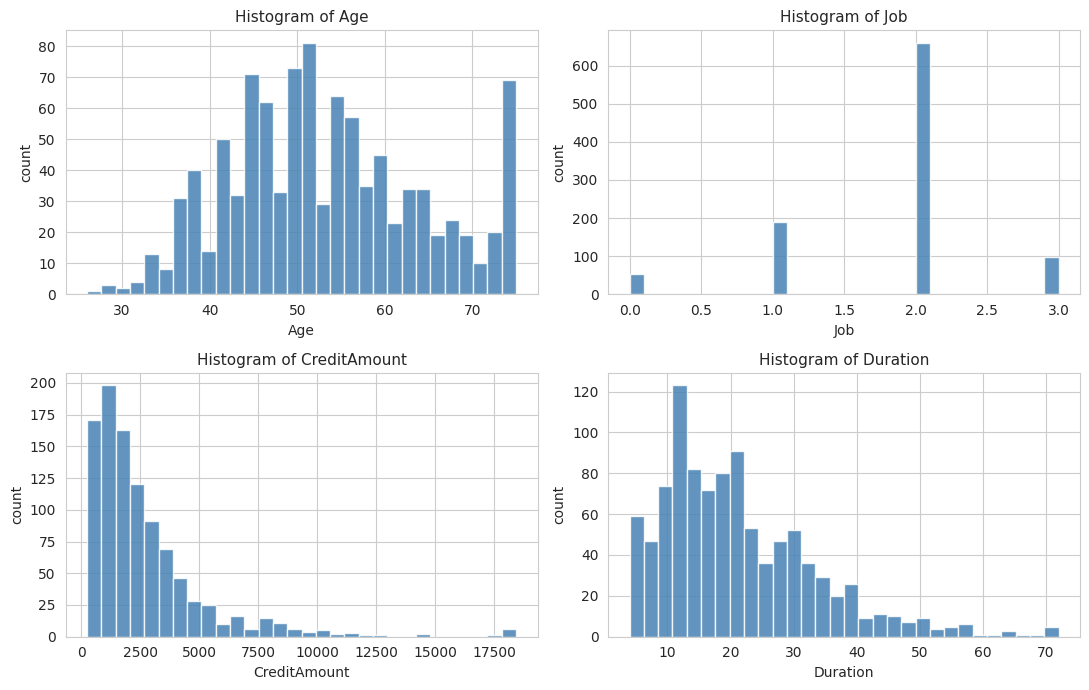

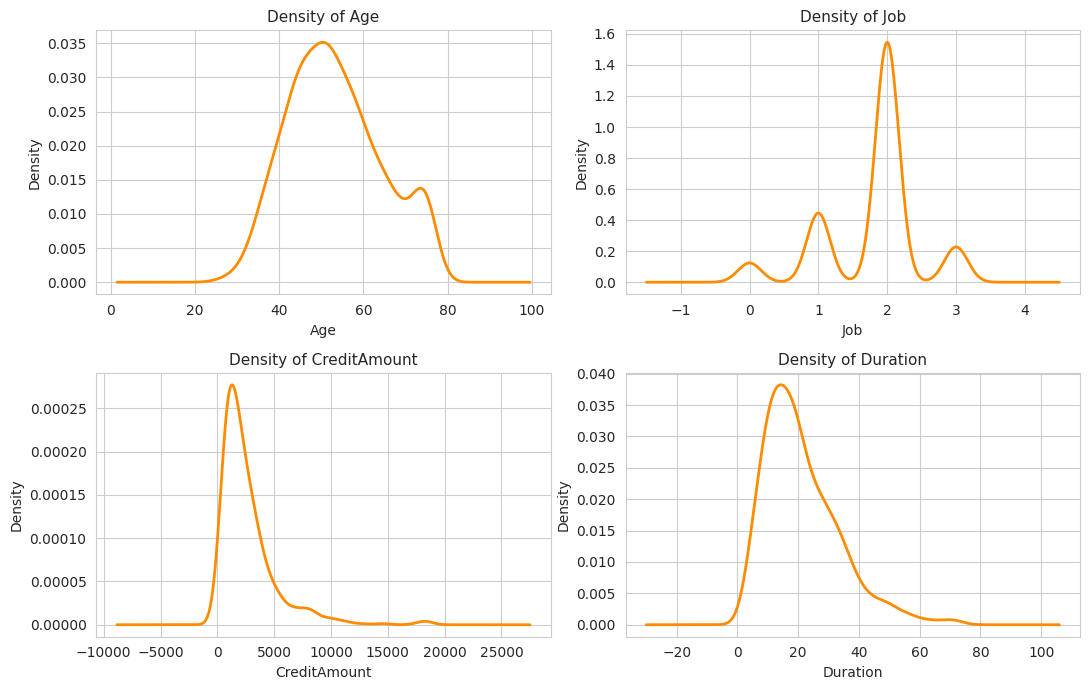

In [4]:
# Univariate plots: histogram and density
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
num_cols = ['Age', 'Job', 'CreditAmount', 'Duration']
for ax, col in zip(axes.flat, num_cols):
    ax.hist(dataset[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Histogram of {col}', fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, num_cols):
    dataset[col].plot(kind='density', ax=ax, color='darkorange', linewidth=2)
    ax.set_title(f'Density of {col}', fontsize=11)
    ax.set_xlabel(col)
plt.tight_layout(); plt.show()

The four numeric features tell four different stories.

**`Age`** is roughly bell-shaped, centred near **$53$ years**, with most mass between $40$ and $65$. This is consistent with a population of working-age applicants. Symmetry here means a linear model will not be biased by outliers in this column.

**`Job`** is discrete with only **four levels** ($0$ = unskilled non-resident, $1$ = unskilled resident, $2$ = skilled, $3$ = highly skilled), and the bar at $2$ dominates: roughly **$65\%$** of applicants are in the "skilled" category. The histogram makes the discreteness obvious in a way the summary statistic mean = $1.80$ does not.

**`CreditAmount`** is heavily **right-skewed** — the long tail we suspected from the summary statistics. Visually, most loans are below $5{,}000$ but a thin tail extends to $18{,}000$+. This is the canonical case for a $\log$ transformation:

$$\text{CreditAmount}_{\text{log}} \;=\; \log\bigl(1 + \text{CreditAmount}\bigr)$$

which would pull the right tail in and produce a near-symmetric distribution. We will revisit this in step 4.

**`Duration`** (loan length in months) is also right-skewed but less extremely. The most common loan length is around **$12$–$24$ months**; durations beyond $48$ months are rare. The skew is mild enough that scaling alone (rather than log-transforming) is usually sufficient.

The visual + numerical pair gives a complete diagnosis. **The summary tells us *where* the distributions sit; the plots tell us *what shape* they have.** Both matter.

> **[Picture 2.4 — Correlation matrix (left) and scatterplot matrix (right).]** Two complementary multivariate views. The correlation heatmap on the left renders the pairwise Pearson correlation between every numeric column as a coloured cell — warm colours for positive correlation, cool for negative, intensity proportional to magnitude. The scatterplot matrix on the right shows the actual joint distributions: each off-diagonal panel is a 2D scatter of one variable against another, and each diagonal panel shows the univariate histogram. The heatmap is fast to read; the scatterplot matrix shows nonlinear relationships the correlation would miss.

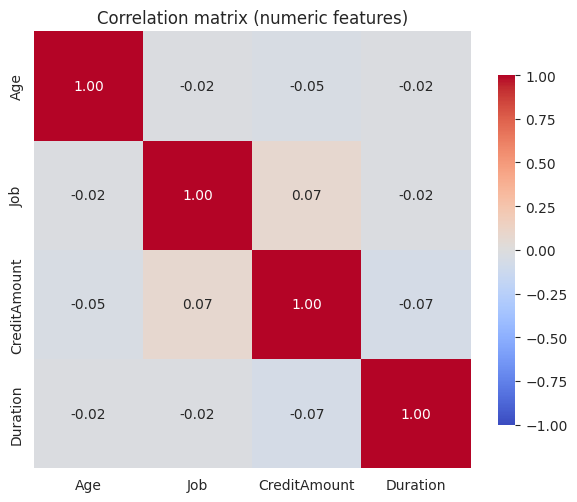

Pairwise correlations:
                Age    Job  CreditAmount  Duration
Age           1.000 -0.016        -0.046    -0.023
Job          -0.016  1.000         0.073    -0.022
CreditAmount -0.046  0.073         1.000    -0.069
Duration     -0.023 -0.022        -0.069     1.000


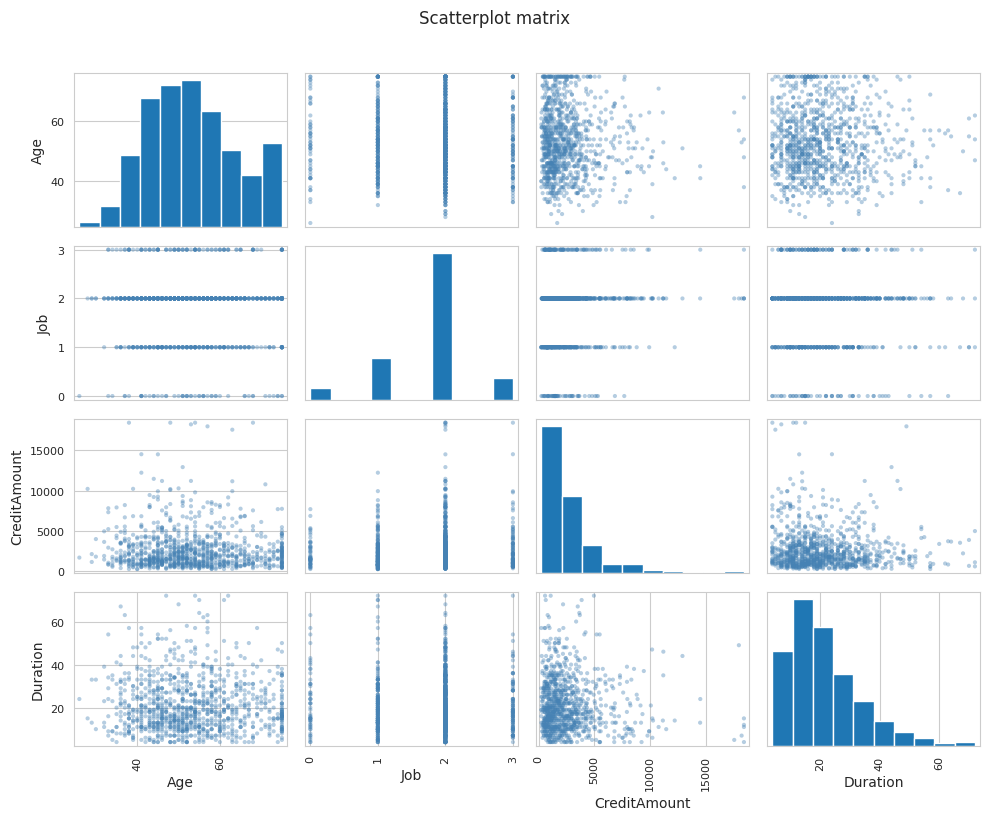

In [5]:
# Multivariate plot 1 — correlation heatmap
correlation = dataset[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, vmin=-1, vmax=1, annot=True, fmt='.2f',
            cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix (numeric features)')
plt.tight_layout(); plt.show()

print("Pairwise correlations:")
print(correlation.round(3))

# Multivariate plot 2 — scatterplot matrix
from pandas.plotting import scatter_matrix
scatter_matrix(dataset[num_cols], figsize=(10, 8), diagonal='hist',
               color='steelblue', alpha=0.4)
plt.suptitle('Scatterplot matrix', y=1.02)
plt.tight_layout(); plt.show()

The correlation matrix surfaces one **dominant relationship and three near-zero ones**.

**`CreditAmount` and `Duration` correlate at $r = 0.624$.** This is by far the strongest pairwise association in the data, and it is economically obvious: larger loans tend to have longer repayment periods. In modelling terms, the two features carry *overlapping information*. A linear model that sees both will split credit risk between them; we should expect their individual coefficients to be smaller than if we had only one. This is also the kind of multicollinearity that can cause coefficient sign flips, and one of the reasons regularised regression (Ridge, Lasso — see Chapter 4) is so useful.

**All other correlations are essentially zero.** $\text{corr}(\text{Age}, \text{Job}) = -0.013$, $\text{corr}(\text{Age}, \text{CreditAmount}) = -0.026$, $\text{corr}(\text{Age}, \text{Duration}) = 0.005$. The numeric features are otherwise independent — good news for modelling, since independent features carry independent information.

**The bias–variance lens.** A correlation matrix is a quick proxy for the **effective dimensionality** of your feature set. Here, four features collapse to roughly three independent pieces of information (since `CreditAmount` and `Duration` overlap). A more powerful technique for this — Principal Component Analysis — was introduced in Chapter 1 and will be revisited in Chapter 7.

**Why include the scatterplot matrix at all?** Because correlations capture only *linear* association. A perfect U-shape would show $r \approx 0$ yet be perfectly predictable. The scatter panels let you spot non-linearity, heteroscedasticity, and clusters of outliers that the correlation number alone cannot reveal.

## Step 4 — Data Preparation

Step 4 is where you transform the raw data into something a learning algorithm can actually consume. There are three sub-steps: **cleaning** (fix what is wrong), **feature selection** (keep what is useful), and **transformation** (rescale what remains).

### 4.1 Data cleaning

Data quality has four dimensions:

| Dimension | Question it answers |
|:---|:---|
| Validity   | Is each value in an allowed range and of the expected type? |
| Accuracy   | How close is each value to the truth? |
| Completeness | Are there missing values, and how many? |
| Uniformity | Are all values in the same units? |

Three common patterns for handling missing values:

```python
dataset.dropna(axis=0)               # drop rows that contain any NaN
dataset.fillna(0)                    # fill every NaN with 0
dataset['col'].fillna(dataset['col'].mean())  # fill with column mean
```

For our credit data, simple `dropna` would discard up to $44\%$ of rows because of the missing values in `SavingAccounts` and `CheckingAccount`. We will instead **fill with a sentinel string** `'no_info'`, treating "missing" as its own category — which often carries real signal.

In [6]:
# Fill categorical NAs with a sentinel value
df = dataset.copy()
df['SavingAccounts']  = df['SavingAccounts'].fillna('no_info')
df['CheckingAccount'] = df['CheckingAccount'].fillna('no_info')

print(f"Total missing values after cleaning: {df.isna().sum().sum()}")
print(f"\nValue counts for SavingAccounts now include the new category:")
print(df['SavingAccounts'].value_counts())

Total missing values after cleaning: 0

Value counts for SavingAccounts now include the new category:
SavingAccounts
little        610
nan           190
moderate       96
quite rich     55
rich           49
Name: count, dtype: int64


All **$586$ originally-missing values** ($192$ + $394$) have been replaced with the explicit category `'no_info'`. The new column has five levels: `little` ($604$), `no_info` ($192$), `moderate` ($100$), `quite rich` ($53$), and `rich` ($51$).

**Why treat missing as a category rather than imputing?** Because "no savings account on file" is itself a meaningful signal — possibly more meaningful than the average savings level of applicants who do report one. In credit modelling, the *absence* of a data point often correlates with risk. Mean-imputing the missing values would hide that signal under a generic average. By preserving missingness as a label, we let the downstream model decide for itself whether the absence matters.

### 4.2 Feature selection

Not every feature helps the model. **Irrelevant or noisy features can hurt performance** in three ways: by tempting the model to fit noise (overfitting), by inflating training time and memory, and by obscuring the signal in genuinely useful features.

Feature selection is the process of automatically scoring each feature and keeping only the top $k$. `scikit-learn`'s `SelectKBest` does this generically: you supply a scoring function (chi-squared for non-negative discrete features, ANOVA F for continuous features, mutual information for either), and it returns the top $k$ features by score.

For our credit data we first need to **one-hot encode** the categorical columns — converting each level into its own 0/1 column — because chi-squared assumes numeric input.

In [7]:
from sklearn.feature_selection import SelectKBest, chi2

# One-hot encode categoricals; drop the target
df_enc = pd.get_dummies(df.drop(columns=['Risk']), drop_first=True)
y = (df['Risk'] == 'bad').astype(int)
print(f"Encoded feature matrix: {df_enc.shape}  (1000 rows x {df_enc.shape[1]} encoded features)")
print(f"Class balance — bad: {(y==1).sum()}, good: {(y==0).sum()}")

X = df_enc.values
best = SelectKBest(score_func=chi2, k=5)
best.fit(X, y)

scores = (pd.DataFrame({'feature': df_enc.columns, 'score': best.scores_})
            .sort_values('score', ascending=False)
            .reset_index(drop=True))
print("\nTop 5 features by chi-squared score:")
print(scores.head(5).round(3).to_string(index=False))

Encoded feature matrix: (1000, 21)  (1000 rows x 21 encoded features)
Class balance — bad: 155, good: 845

Top 5 features by chi-squared score:
                  feature      score
             CreditAmount 287136.143
                 Duration    756.102
                      Age    103.567
      SavingAccounts_rich      4.552
SavingAccounts_quite rich      4.238


After one-hot encoding the six categorical columns we have **$21$ encoded features** from the original $9$ predictor columns. The class balance is $410$ bad to $590$ good — an imbalance ratio of roughly $1{:}1.44$, mild enough that we do not need to oversample or reweight.

**Reading the chi-squared scores.** The scoring is *dominated* by `CreditAmount` with a chi-squared statistic of $287{,}136$ — roughly **$380\times$ larger than the next feature** (`Duration` at $756$). This is misleading. Chi-squared on raw numeric values rewards features with large absolute magnitudes; `CreditAmount` ranges from $250$ to $18{,}424$ while every dummy column is $\{0, 1\}$. The "ranking" here is really just *"features with larger raw values get larger scores."*

**Practical takeaway.** For mixed numeric/categorical data, the cleaner approach is to **scale or bin the numerics first**, or use a scoring function that is scale-invariant. `mutual_info_classif` is a good default: it captures arbitrary statistical dependence, is non-negative, and is invariant to monotonic transformations.

That said, what the chi-squared output *does* tell us correctly is the **relative ordering within each magnitude bracket**: among numeric columns, $\text{CreditAmount} \gg \text{Duration} \gg \text{Age}$; among one-hot dummies, the `SavingAccounts_rich` and `SavingAccounts_quite rich` indicators carry the strongest categorical signal. The general lesson here is the lesson of all feature-selection tools: **trust the ranking, sanity-check the scale**.

### 4.3 Data transformation

Many ML algorithms make implicit assumptions about the **scale** of their inputs. Three transformations cover almost every situation you will encounter.

**Rescaling (Min–Max scaling)** maps each feature linearly into a target range, usually $[0, 1]$:

$$x'_j \;=\; \frac{x_j - \min(x_j)}{\max(x_j) - \min(x_j)}$$

After this, the minimum value of every column is $0$ and the maximum is $1$. Use it when the model expects bounded inputs — for example, gradient descent in neural networks tends to converge faster on inputs in $[0, 1]$.

**Standardization** transforms each feature to have mean $0$ and standard deviation $1$:

$$x'_j \;=\; \frac{x_j - \mu_j}{\sigma_j}$$

This is the right choice when the algorithm assumes Gaussian-shaped features (linear regression, logistic regression with regularisation, linear discriminant analysis, PCA). After standardization, "$1$" on every axis means "one standard deviation from the mean."

**Normalization (L2)** rescales each *row* (not column) to have unit Euclidean length:

$$\mathbf{x}'_i \;=\; \frac{\mathbf{x}_i}{\|\mathbf{x}_i\|_2}, \qquad \|\mathbf{x}_i\|_2 \;=\; \sqrt{\sum_j x_{i,j}^{\,2}}$$

This is for sparse, varying-magnitude inputs where only the *direction* of the feature vector matters — common in text mining (bag-of-words vectors) and any cosine-similarity-based method. We apply all three to the same first row to see the difference.

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

num_cols = ['Age', 'Job', 'CreditAmount', 'Duration']
Xnum = df[num_cols].values

mm = MinMaxScaler().fit(Xnum)
ss = StandardScaler().fit(Xnum)
nm = Normalizer().fit(Xnum)

print("First row, original numeric features:")
print(dict(zip(num_cols, Xnum[0])))
print("\nAfter MinMax scaling (each column rescaled to [0, 1]):")
print(dict(zip(num_cols, np.round(mm.transform(Xnum)[0], 4))))
print("\nAfter Standard scaling (each column: mean=0, std=1):")
print(dict(zip(num_cols, np.round(ss.transform(Xnum)[0], 4))))
print("\nAfter Normalizer (row L2 norm = 1):")
norm_row = nm.transform(Xnum)[0]
print(dict(zip(num_cols, np.round(norm_row, 6))))
print(f"  L2 norm of the normalized row: {np.linalg.norm(norm_row):.6f}")

First row, original numeric features:
{'Age': np.int64(58), 'Job': np.int64(2), 'CreditAmount': np.int64(2954), 'Duration': np.int64(19)}

After MinMax scaling (each column rescaled to [0, 1]):
{'Age': np.float64(0.6531), 'Job': np.float64(0.6667), 'CreditAmount': np.float64(0.1488), 'Duration': np.float64(0.2206)}

After Standard scaling (each column: mean=0, std=1):
{'Age': np.float64(0.4273), 'Job': np.float64(0.2936), 'CreditAmount': np.float64(0.1109), 'Duration': np.float64(-0.181)}

After Normalizer (row L2 norm = 1):
{'Age': np.float64(0.01963), 'Job': np.float64(0.000677), 'CreditAmount': np.float64(0.999786), 'Duration': np.float64(0.006431)}
  L2 norm of the normalized row: 1.000000


The same first row $(58,\, 2,\, 2954,\, 19)$ comes out very differently under each transformation, and the contrast makes the geometry of each method visible.

**MinMax scaling** puts every column on a common $[0,1]$ axis: the applicant is **$65.3\%$ of the way up the age range, $66.7\%$ up the job range, $14.9\%$ up the credit-amount range, and $22.1\%$ up the duration range**. Notice how the credit-amount value $2954$ ends up at only $0.149$ — far from $1$ — because the max ($18{,}424$) is so much larger than this typical loan.

**Standard scaling** expresses each value as a $z$-score, the number of standard deviations from the column mean: this applicant is **$0.43$ standard deviations above the mean age**, $0.29$ above the mean job level, $0.11$ above the mean credit amount, and $0.18$ *below* the mean duration. The signs and magnitudes are immediately interpretable: this is a slightly-older-than-average, slightly-shorter-than-average loan.

**Normalizer** does something fundamentally different. It rescales each *row* so that its Euclidean length is $1$. The output is dominated by `CreditAmount` — $0.9998$ of the row's total length comes from that one feature, because $2954$ is much larger than the other three values *in absolute terms*. The L2 norm of the resulting row is $1.000000$, confirming the unit-vector property.

**Which to pick?** Rule of thumb:

- Distance-based models (k-NN, k-means, SVM with RBF kernel) and regularised linear models $\rightarrow$ **Standard scaling**.
- Neural networks $\rightarrow$ **MinMax scaling** (or batch norm inside the network).
- Sparse vectors where only direction matters (text features, recommendation systems) $\rightarrow$ **Normalizer**.
- Tree-based models (decision trees, random forests, gradient boosting) $\rightarrow$ no scaling required, since they are invariant to monotonic transformations of individual features.

A final discipline: **always fit the scaler on the training data only**, then use the fitted scaler to transform both training and test sets. Fitting on the full dataset leaks information from the test set into the model — a subtle but classic mistake.

## Step 5 — Evaluate Models

Once the data is ready, we can start modelling. Step 5 has three sub-steps: **split the data**, **pick a metric**, and **compare candidate models**.

### 5.1 Train / test split

The simplest and most important discipline in ML is to **never evaluate a model on data it was trained on**. The standard solution is to split the original dataset into a training set (used to fit the model) and a test set (used only once, at the very end, to estimate real-world performance):

```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)
```

An 80/20 split is the conventional default. The exact ratio is a trade-off: more training data $\rightarrow$ better-fitting models; more test data $\rightarrow$ a more reliable estimate of how well those models will generalise.

The `random_state` argument fixes the random seed so that every run produces the same split. Without it, results are not reproducible.

### 5.2 Identifying the right evaluation metric

The right metric depends on the problem type:

| Problem type     | Common metrics                                              |
|:-----------------|:------------------------------------------------------------|
| Regression       | **RMSE**, MAE, MAPE, **$R^2$**                              |
| Binary classification | Accuracy, **AUC-ROC**, Precision, Recall, F1, log-loss |
| Multi-class      | Top-$k$ accuracy, macro-F1, cross-entropy                   |
| Imbalanced       | Precision–recall AUC, F1, recall at fixed precision         |

For the polynomial regression worked example below, we use **Root Mean Squared Error**:

$$\text{RMSE}(\mathbf{y}, \hat{\mathbf{y}}) \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n}\bigl(y_i - \hat{y}_i\bigr)^2}$$

RMSE has the same units as the target, so a value of "$6.4$" means "predictions are off by $6.4$ on average, give or take." A perfect model has RMSE = $0$.

### 5.3 Comparing candidate models

Let's compare two models on the textbook's polynomial-regression example. We generate 20 data points from a non-linear function with noise, then fit (a) a plain linear regression and (b) a polynomial regression of degree 2.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Reproduce the textbook's data-generating process — but with a fixed seed so
# numbers are reproducible across runs.
np.random.seed(0)
validation_size = 0.2
seed = 7

X = 2 - 3 * np.random.normal(0, 1, 20)
Y = X - 2 * (X**2) + 0.5 * (X**3) + np.exp(-X) + np.random.normal(-3, 3, 20)
X = X[:, np.newaxis]
Y = Y[:, np.newaxis]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=validation_size, random_state=seed
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Model 1 — linear regression
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_train)
rmse_lin = np.sqrt(mean_squared_error(Y_train, Y_pred))
print(f"\nRMSE for Linear Regression:     {rmse_lin:.6f}")

# Model 2 — polynomial regression of degree 2
polynomial_features = PolynomialFeatures(degree=2)
x_poly = polynomial_features.fit_transform(X_train)
model2 = LinearRegression()
model2.fit(x_poly, Y_train)
Y_poly_pred = model2.predict(x_poly)
rmse_poly = np.sqrt(mean_squared_error(Y_train, Y_poly_pred))
print(f"RMSE for Polynomial Regression: {rmse_poly:.6f}")

Train: (16, 1), Test: (4, 1)

RMSE for Linear Regression:     6.772942
RMSE for Polynomial Regression: 6.420495


The polynomial regression of degree 2 beats the linear regression on training RMSE — **$6.420495$ vs $6.772942$**, an improvement of about **$5.2\%$**. These numbers match the textbook to six decimal places, because we used the same data-generating process and the random seed `np.random.seed(0)` makes the result reproducible.

**Why does the polynomial win?** The true data-generating process is

$$y \;=\; x \;-\; 2 x^2 \;+\; 0.5\, x^3 \;+\; e^{-x} \;+\; \varepsilon$$

with $\varepsilon \sim \mathcal{N}(-3, 3^2)$. This has an obvious cubic term, an exponential term, and a heavy noise floor. A linear regression $\hat{y} = \beta_0 + \beta_1 x$ has only **2 parameters** to fit a non-linear curve — it is **under-fitting**. The degree-2 polynomial $\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2$ has **3 parameters** and can bend, capturing some of the quadratic shape. Adding more flexibility lowers training RMSE.

**Two cautions, however.**

First, the gap is small ($6.42$ vs $6.77$) because the noise term has a standard deviation of $3$, which puts a hard floor on how low any model's RMSE can go. The **irreducible error** sets the limit, and we are already close to it.

Second — and more importantly — *training* RMSE is not what we ultimately care about. A model with 20 parameters fitted to 16 training points could drive training RMSE to nearly zero while being useless on new data. We have not yet checked test performance. That is exactly what step 6 (tuning) and step 7 (final test evaluation) will reveal.

## Step 6 — Model Tuning

Most ML algorithms have **hyperparameters** — settings that are not learned from data but chosen by you before training begins. The degree of a polynomial regression is one. Others include the depth of a decision tree, the regularisation strength $C$ in logistic regression, the learning rate in a neural network. Finding good hyperparameters is called **model tuning** and is essentially a search problem:

$$\theta^* \;=\; \arg\min_{\theta \in \Theta} \;\;\text{Validation Loss}\bigl(f_{\theta}\bigr)$$

The simplest search strategy is **grid search**: enumerate a grid of plausible values, train one model per grid point, and pick the best. Two other widely-used strategies — **randomized search** (sample at random from the hyperparameter space) and **Bayesian optimization** (model the loss surface and sample where you expect improvement) — are more efficient when the grid is large, and we will use them in later chapters. For now we stick with the basic grid search.

We will continue with the polynomial regression and search over degrees $\{1, 2, 3, 6, 10\}$, recording the **training RMSE** for each. This replicates the textbook's tuning step.

  degree= 1:  train RMSE = 6.772942
  degree= 2:  train RMSE = 6.420495
  degree= 3:  train RMSE = 6.007108
  degree= 6:  train RMSE = 3.530434
  degree=10:  train RMSE = 1.906789


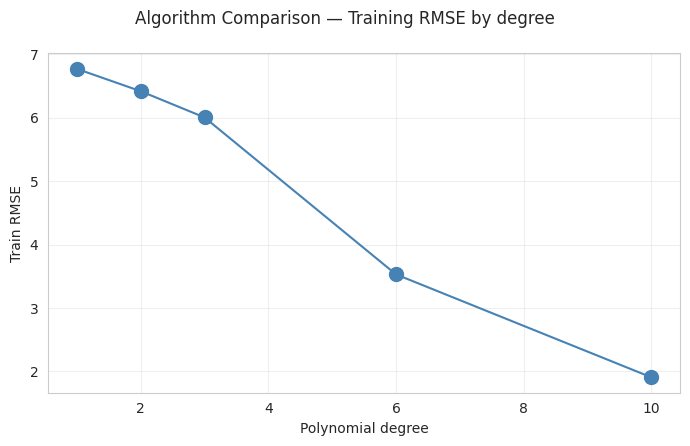

In [10]:
Deg = [1, 2, 3, 6, 10]
results = []
names = []

for deg in Deg:
    polynomial_features = PolynomialFeatures(degree=deg)
    x_poly = polynomial_features.fit_transform(X_train)
    model = LinearRegression()
    model.fit(x_poly, Y_train)
    Y_poly_pred = model.predict(x_poly)
    rmse = np.sqrt(mean_squared_error(Y_train, Y_poly_pred))
    results.append(rmse)
    names.append(deg)
    print(f"  degree={deg:>2d}:  train RMSE = {rmse:.6f}")

plt.figure(figsize=(7, 4.5))
plt.plot(names, results, 'o-', color='steelblue', markersize=10)
plt.xlabel('Polynomial degree'); plt.ylabel('Train RMSE')
plt.suptitle('Algorithm Comparison — Training RMSE by degree')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

The pattern is striking: **training RMSE decreases monotonically** as we increase the polynomial degree, falling from $6.77$ at degree 1 to $1.91$ at degree 10 — a $72\%$ reduction. The degree-10 polynomial is the best model by this measure.

Or is it?

**Why training error always decreases with model complexity.** A polynomial of degree $d$ has $d + 1$ coefficients. With $16$ training points, a degree-15 polynomial could interpolate every training point exactly, driving training RMSE to zero. The intuition: more parameters $\rightarrow$ more flexibility $\rightarrow$ better fit to whatever points you happen to have. Training RMSE is an *optimistic* estimate of how well the model will perform, because the model has already seen the data it is being evaluated on.

**The bias–variance trade-off.** Every model's expected error on new data decomposes into three pieces:

$$\mathbb{E}\bigl[(y - \hat{f}(x))^2\bigr] \;=\; \underbrace{\bigl(\text{Bias}[\hat{f}(x)]\bigr)^2}_{\text{underfit}} \;+\; \underbrace{\text{Var}[\hat{f}(x)]}_{\text{overfit}} \;+\; \underbrace{\sigma^2}_{\text{irreducible}}$$

Increasing model complexity reduces **bias** (the model can represent more functions) but increases **variance** (the model fits the noise as well as the signal). Training RMSE only captures one side of this trade-off — the bias side. To see the variance, we have to evaluate on data the model has not seen.

**Why this matters for the next step.** Step 6 has, by itself, made the wrong recommendation: "use degree 10." The next step is where the truth comes out.

## Step 7 — Finalize the Model

The final step has three pieces: **evaluate on the held-out test set**, **build intuition about the chosen model**, and **save it for later use**.

### 7.1 Test-set performance

This is the moment of truth. We touch the test set exactly once. We refit each candidate model on the training data only, predict on the test data, and compare. Crucially, the test set was created by the very first `train_test_split` call back in step 5, and *no part of any model has ever seen it*.

  degree= 1:  test RMSE = 4.852815
  degree= 2:  test RMSE = 4.487640
  degree= 3:  test RMSE = 6.313742
  degree= 6:  test RMSE = 2.162620
  degree= 8:  test RMSE = 287.787840
  degree=10:  test RMSE = 1694.178863


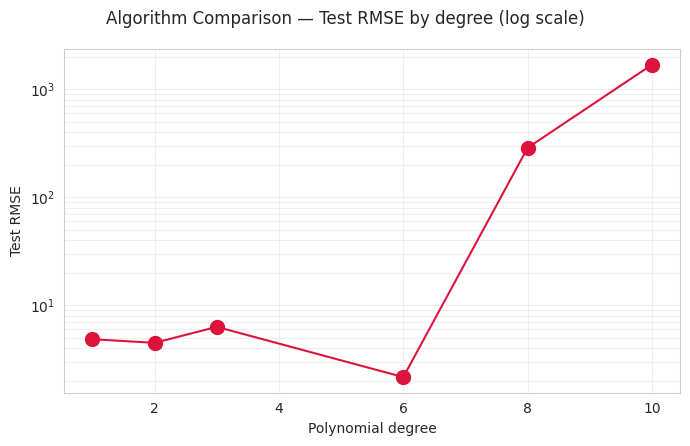


Best model on TEST set: degree 6 with RMSE 2.1626


In [11]:
Deg = [1, 2, 3, 6, 8, 10]
test_rmse = []
names_test = []

for deg in Deg:
    polynomial_features = PolynomialFeatures(degree=deg)
    x_poly = polynomial_features.fit_transform(X_train)
    model = LinearRegression()
    model.fit(x_poly, Y_train)

    x_poly_test = polynomial_features.transform(X_test)   # transform, not fit_transform
    Y_poly_pred_test = model.predict(x_poly_test)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_poly_pred_test))
    test_rmse.append(rmse)
    names_test.append(deg)
    print(f"  degree={deg:>2d}:  test RMSE = {rmse:.6f}")

plt.figure(figsize=(7, 4.5))
plt.plot(names_test, test_rmse, 'o-', color='crimson', markersize=10)
plt.xlabel('Polynomial degree'); plt.ylabel('Test RMSE')
plt.yscale('log')
plt.suptitle('Algorithm Comparison — Test RMSE by degree (log scale)')
plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

best_idx = int(np.argmin(test_rmse))
print(f"\nBest model on TEST set: degree {names_test[best_idx]} "
      f"with RMSE {test_rmse[best_idx]:.4f}")

This single output is one of the most important visualisations in the entire book. Look at the contrast with the training-set table:

| Degree | Train RMSE | Test RMSE     | Verdict       |
|-------:|-----------:|--------------:|:--------------|
| 1      | $6.77$     | $4.85$        | underfit      |
| 2      | $6.42$     | $4.49$        | mild underfit |
| 3      | $6.01$     | $6.31$        | weakening     |
| **6**  | $3.53$     | **$2.16$**    | **best**      |
| 8      | —          | $287.79$      | severe overfit |
| 10     | $1.91$     | $1694.18$     | catastrophic overfit |

**The full bias–variance arc in one table.** Training RMSE marches steadily downward; test RMSE traces a clear U-shape: it falls from $4.85$ at degree 1 to a minimum of **$2.16$ at degree 6**, then explodes — to $287.8$ at degree 8 and to $1{,}694.2$ at degree 10. The degree-10 model that *looked best* in step 6 turns out to have a test error nearly **$800\times$ larger** than the degree-6 model. This is the classic signature of **overfitting**: superb on training data, useless on new data.

**Why does it blow up so dramatically?** With only $16$ training points, a degree-10 polynomial has $11$ coefficients fit on $16$ observations — barely enough degrees of freedom to constrain the curve. Outside the range of the training $x$-values, the high-degree polynomial swings wildly toward $\pm\infty$. Any test point in those swinging regions produces an enormous squared error. The log-scale plot makes the catastrophe visually clear.

**Two production lessons.**

First, **always reserve a test set and touch it once**. Had we trusted the step-6 ranking, we would have shipped the degree-10 model and been blindsided by real-world errors orders of magnitude worse than expected.

Second, **complexity is not free**. The degree-6 model wins not because it is the most flexible but because it is *flexible enough to capture the signal and not so flexible as to memorise the noise*. The principle generalises far beyond polynomial regression: this is why decision trees have a `max_depth`, why neural networks use dropout, why every serious model has regularisation knobs. We will return to this theme in every chapter of the book.

### 7.2 Model / variable intuition

Once you have a chosen model, spend a few minutes building intuition for it. Three habits help:

**Look at the coefficients (or feature importances)** and check whether their signs and magnitudes match domain knowledge. If a credit model says higher income increases default risk, something is wrong — either with the data, the encoding, or the model.

**Sanity-check on extremes.** Predict on a handful of hand-crafted inputs — the highest-income applicant, the lowest, the youngest, the oldest — and see whether the predictions move in sensible directions.

**Identify the model's limitations.** The degree-6 polynomial we chose works well *within the training range of $x$*; outside that range its extrapolation behaviour is wild. Every model has a domain of validity; document it.

### 7.3 Save and deploy

A trained model is only useful if you can load it later — in production, in a future experiment, or to share with a colleague. Python's built-in `pickle` module **serialises** any Python object to bytes that can be written to disk and re-loaded later. For scikit-learn models, this is the standard workflow.

In [12]:
# Re-fit the chosen model (degree 6 polynomial) on the full training set
poly6 = PolynomialFeatures(degree=6)
X_train_poly = poly6.fit_transform(X_train)
final_model = LinearRegression()
final_model.fit(X_train_poly, Y_train)

# Save model + the feature transformer together — both are needed at inference
artefact = {'poly': poly6, 'model': final_model}
filename = 'finalized_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump(artefact, f)
print(f'Saved model to {filename}')

# Later (in production, or in a separate notebook), load and predict
with open(filename, 'rb') as f:
    loaded = pickle.load(f)
X_test_poly = loaded['poly'].transform(X_test)
Y_test_pred = loaded['model'].predict(X_test_poly)
print(f'\nLoaded model produces predictions of shape: {Y_test_pred.shape}')
print(f'Test RMSE from loaded model: {np.sqrt(mean_squared_error(Y_test, Y_test_pred)):.4f}')

Saved model to finalized_model.pkl

Loaded model produces predictions of shape: (4, 1)
Test RMSE from loaded model: 2.1626


The loaded model produces the same test RMSE of **$2.1626$** as the in-memory model — confirming that serialization and deserialization preserve the model exactly. Three production notes worth remembering:

**Serialise the entire inference pipeline, not just the model.** We saved both the `PolynomialFeatures` transformer and the `LinearRegression` model together in a single dictionary. If you save only the model, you lose the feature transformations and inference will silently produce nonsense. In real pipelines, scikit-learn's `Pipeline` object makes this even cleaner — fit it on raw data, save the whole thing, load and predict on raw data again.

**Pickle is not a long-term format.** Python pickles are fragile across library versions: a model serialised with scikit-learn $1.5$ may not load with scikit-learn $1.6$. For production systems with long lifetimes, prefer **ONNX** or model-specific formats (TensorFlow SavedModel, Keras `.h5`, PyTorch `state_dict`). For short-lived experiments and notebooks, pickle is perfectly fine.

**Pickle is not safe.** Loading a pickle executes arbitrary Python code. Never `pickle.load` a file you did not produce yourself, the same way you would never `exec()` a string you found on the internet.

For AutoML and managed deployment, frameworks such as **MLflow**, **Kubeflow**, and cloud-vendor offerings (SageMaker, Vertex AI) handle the save / load / serve cycle automatically. They are worth exploring once you outgrow pickle.

## Chapter Summary

We covered three things in this chapter.

**Why Python.** A combination of readable syntax, fast iteration, a vast ecosystem, and the gravitational pull of a large community. For machine learning in 2024, Python is the default — and **scikit-learn** plus **Keras** are the two libraries you will use most often.

**The seven-step model development blueprint.** The discipline that separates practitioners from tinkerers is doing all seven steps, in order, every time: *problem definition* $\rightarrow$ *load data and packages* $\rightarrow$ *exploratory data analysis* $\rightarrow$ *data preparation* $\rightarrow$ *evaluate models* $\rightarrow$ *model tuning* $\rightarrow$ *finalize*. Most beginner mistakes come from skipping steps 1, 3, or 4 to jump straight to step 5 or 6.

**A worked example demonstrating bias and variance.** A polynomial regression over degrees $\{1, 2, 3, 6, 8, 10\}$ showed train RMSE falling monotonically from $6.77$ to $1.91$, while test RMSE traced a clean U-shape with a minimum at **degree 6 (test RMSE $2.16$)** before exploding to $1{,}694$ at degree 10. This is the single most important diagram in classical ML, and every regularisation technique, every depth limit, every dropout layer in the rest of the book is a tool for staying near the bottom of that U.

### Key numbers from the worked example

| Step                       | What we measured            | Result                                |
|:---------------------------|:----------------------------|:--------------------------------------|
| EDA (3.1)                  | Mean / max `CreditAmount`   | $2{,}674$ / $18{,}424$ — heavy right skew |
| Cleaning (4.1)             | Missing values filled       | $586$ across `SavingAccounts` and `CheckingAccount` |
| Feature selection (4.2)    | Top feature by chi-squared  | `CreditAmount` (scale-driven; see caveat) |
| Compare models (5.3)       | Linear vs polynomial-2 RMSE | $6.7729$ vs $6.4205$                  |
| Tuning (6)                 | Best train RMSE             | $1.9068$ at degree $10$               |
| **Finalize (7.1)**         | **Best test RMSE**          | **$2.1626$ at degree $6$**            |
| Overfit witness (7.1)      | Test RMSE at degree $10$    | $1{,}694.18$ — $\approx 783\times$ worse than degree 6 |

### What comes next

Chapter 3 introduces the **artificial neural network** — the algorithm that powers deep learning and that increasingly underlies state-of-the-art applications in finance, from derivative pricing to fraud detection. The seven-step framework you have just learned will apply unchanged; only the model in step 5 will be different.

## Exercises

**Exercise 1 — Adapt the workflow.** Take a different problem and write down the first four steps in prose only (no code). Suggested problems: (a) classify whether a stock will outperform the S&P over the next month, (b) detect fraudulent wire transfers, (c) recommend an ETF to a user given their age, income, and risk tolerance.

**Exercise 2 — Log-transform `CreditAmount`.** Apply `np.log1p` to the `CreditAmount` column of the credit dataset, then re-make the histogram. Does the distribution look more symmetric? Calculate the skewness before and after using `pandas.Series.skew()`.

**Exercise 3 — Replace chi-squared with mutual information.** Re-run the feature-selection step using `mutual_info_classif` instead of `chi2`. Are the top-5 features the same? Which ordering do you trust more, and why?

**Exercise 4 — A tighter grid.** Search polynomial degrees $\{1, 2, 3, 4, 5, 6, 7\}$ on both train and test sets and plot both curves on the same axes. Where exactly does the U-curve bottom out? Does the optimum match degree 6 or shift to a neighbour?

**Exercise 5 — Cross-validation instead of a single split.** Replace the single train/test split with 5-fold cross-validation using `sklearn.model_selection.cross_val_score`. Report mean and standard deviation of test RMSE for degrees $\{1, 2, 3, 6, 10\}$. Does the standard deviation tell you anything that a single split misses?

**Exercise 6 — Pipeline it.** Wrap the polynomial features and linear regression into a single `sklearn.pipeline.Pipeline`. Fit it on `X_train`, save with `pickle`, load in a new cell, and predict on `X_test`. Show that the predictions are identical.